In [ ]:
from pathlib import Path

from aereo.backends import LocalProcessBackend
from aereo.client import AereoClient
from aereo.pipeline import ExtractionJob

# Assumes this notebook is launched from the examples/ directory.
config_dir = (Path(".") / "config").resolve()
client = AereoClient()
job = ExtractionJob.load_from_config(
    config_dir=config_dir,
    config_name="job_goes19",
)

In [ ]:
# Search
search_results = client.search(job.search)
print(f"✓ Found {len(search_results)} scenes")

In [ ]:
search_results

In [ ]:
# Prepare
print("\n📦 Preparing tasks...")
tasks = client.prepare_tasks(
    search_results=search_results,
    job=job,
    cells_per_task=2,
)
print(f"✓ Prepared {len(tasks)} tasks")

In [ ]:
# Extract
print("\n⛏️ Extracting...")
backend = LocalProcessBackend(max_workers=2)
artifacts = client.execute_tasks(tasks, backend=backend)
print(f"✓ Extracted {len(artifacts)} artifacts")

(<Figure size 2000x2332.09 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


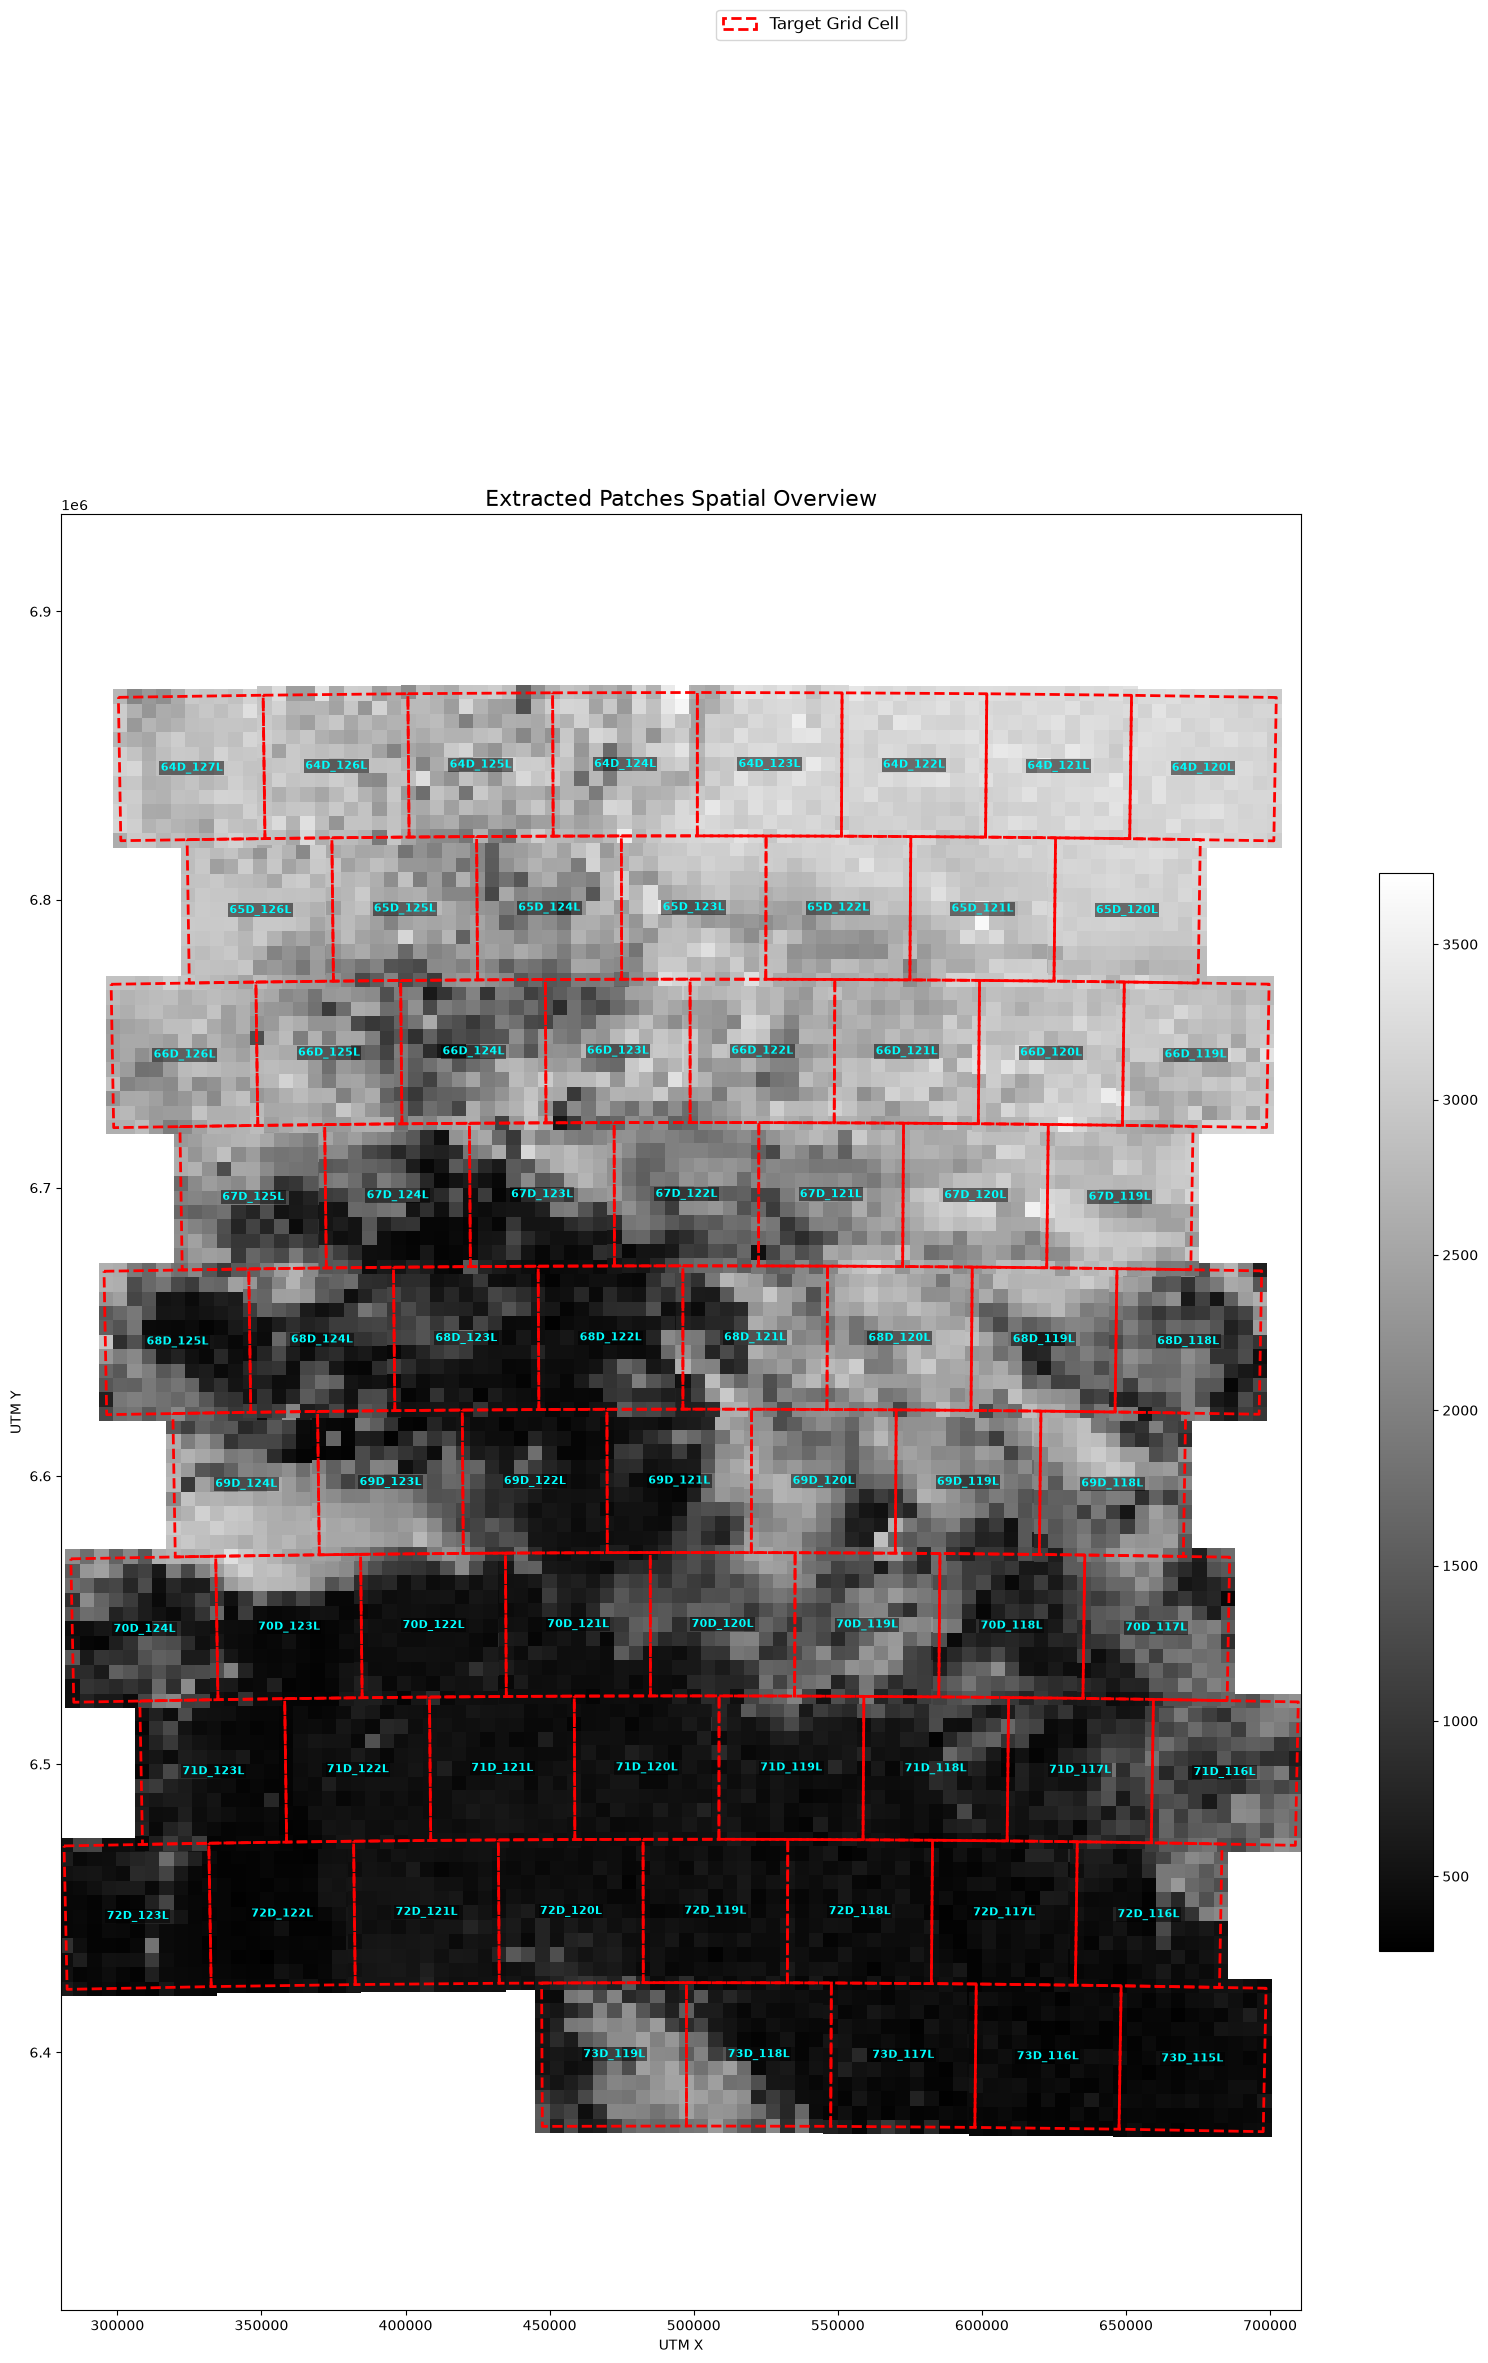

In [ ]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, cmap="viridis")